In [25]:
from sage.groups.braid import BraidGroup

class TorusKnot:
    """
    A class representing a torus knot with associated binary lists.
    
    Each TorusKnot object contains:
    - list1: A binary list (elements are 0 or 1)
    - list2: A binary list (elements are 0 or 1)
    - braid: A Braid object from SageMath's BraidGroup
    """

    def __init__(self, list1, list2, braid_word=None):
        """Initialize a TorusKnot object.

        The two binary lists may have different lengths, but they must contain
        the same number of 1s.
        """

        # Validate that lists are binary (contain only 0s and 1s)
        for lst in [list1, list2]:
            if not all(x in [0, 1] for x in lst):
                raise ValueError("Lists must be binary (contain only 0s and 1s)")

        if sum(list1) != sum(list2):
            raise ValueError("Lists must contain the same number of 1s")

        # store lists
        self.list1 = list(list1)
        self.list2 = list(list2)

        # save braid word (as provided) for fallback permutation computation
        self.braid_word = list(braid_word) if braid_word is not None else []

        # Number of strands is the sum of the lengths minus the number of ones in list2
        self.n = len(self.list1) + len(self.list2) - sum(self.list2)
        if self.n <= 0:
            raise ValueError("Number of strands must be positive after applying rule")

        # Create the braid with number of strands equal to the sum
        self.braid_group = BraidGroup(self.n)

        if braid_word is None:
            self.braid = self.braid_group.one()
        else:
            self.braid = self.braid_group(braid_word)

    def __repr__(self):
        return (f"TorusKnot(list1={self.list1}, list2={self.list2}, braid={self.braid})")

    def __str__(self):
        return (f"Torus Knot:\n  Binary list 1: {self.list1}\n  Binary list 2: {self.list2}\n  Braid: {self.braid}")

    def _compute_permutation_from_word(self):
        """Compute the strand permutation induced by the braid word (fallback)."""
        if not self.braid_word:
            return list(range(self.n))
        positions = list(range(self.n))
        for g in self.braid_word:
            idx = abs(int(g)) - 1
            if idx < 0 or idx + 1 >= self.n:
                continue
            positions[idx], positions[idx + 1] = positions[idx + 1], positions[idx]
        perm = [0] * self.n
        for final_pos, orig in enumerate(positions):
            perm[orig] = final_pos
        return perm

    def _strand_components(self):
        """Return component id for each strand index (0-based)."""
        perm = None
        try:
            if hasattr(self.braid, 'permutation'):
                p = self.braid.permutation()
                perm = [p(i + 1) - 1 for i in range(self.n)]
            elif hasattr(self.braid, 'to_permutation'):
                p = self.braid.to_permutation()
                perm = [p(i + 1) - 1 for i in range(self.n)]
        except Exception:
            perm = None

        if perm is None:
            perm = self._compute_permutation_from_word()

        visited = [False] * self.n
        comp_id = [-1] * self.n
        cid = 0
        for i in range(self.n):
            if visited[i]:
                continue
            cycle = []
            cur = i
            while not visited[cur]:
                visited[cur] = True
                cycle.append(cur)
                cur = perm[cur]
            for v in cycle:
                comp_id[v] = cid
            cid += 1
        return comp_id

    def simplify_by_first_braid_letter(self):
        """Apply the simplification rule based on the first braid letter."""
        if not self.braid_word:
            return False
        try:
            i = abs(int(self.braid_word[0])) - 1
        except Exception:
            return False
        if i >= len(self.list1) - 1:
            return False
        if self.list1[i+1] != 1:
            return False
        self.list1[i], self.list1[i+1] = self.list1[i+1], self.list1[i]
        self.braid_word.pop(0)
        try:
            if self.braid_word:
                self.braid = self.braid_group(self.braid_word)
            else:
                self.braid = self.braid_group.one()
        except Exception:
            pass
        return True

    def visualize(self, figsize=(6,4), show=True, savepath=None):
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=figsize)
        width = 1.75
        inset = 0.12

        ax.plot([0, width, width, 0, 0], [0, 0, 1, 1, 0], color='black')

        n1 = len(self.list1)
        if n1 == 0:
            left_xs, left_ys = [], []
        elif n1 == 1:
            left_xs, left_ys = [0.0], [0.5]
        else:
            left_xs = [0.0] * n1
            left_ys = [inset + i * ((1 - 2 * inset) / (n1 - 1)) for i in range(n1)]

        n2 = len(self.list2)
        if n2 == 0:
            bottom_xs, bottom_ys = [], []
        elif n2 == 1:
            bottom_xs, bottom_ys = [width / 2], [0.0]
        else:
            bottom_xs = [inset + i * ((width - 2 * inset) / (n2 - 1)) for i in range(n2)]
            bottom_ys = [0.0] * n2

        zero_indices = [i for i, value in enumerate(self.list2) if value == 0]
        top_xs_all = [bottom_xs[i] for i in zero_indices]
        top_ys_all = [1.0] * len(top_xs_all)
        top_zero_indices = sorted(zero_indices, key=lambda i: bottom_xs[i])

        extra_left = max(0, n1 - n2)
        extra_bottom = max(0, n2 - n1)

        top_extension_count = min(len(top_zero_indices), extra_bottom)
        top_to_bottom_indices = top_zero_indices[:top_extension_count]
        remaining_top_zero_indices = top_zero_indices[top_extension_count:]
        remaining_bottom_indices = list(range(n1 + top_extension_count, n2)) if extra_bottom > top_extension_count else []

        rhs_count = extra_left + len(remaining_top_zero_indices) + len(remaining_bottom_indices)
        if rhs_count > 0:
            right_xs = [width] * rhs_count
            right_ys = [inset + i * ((1 - 2 * inset) / (rhs_count - 1)) for i in range(rhs_count)] if rhs_count > 1 else [0.5]
        else:
            right_xs, right_ys = [], []

        segments = []
        pair_count = min(n1, n2)
        for i in range(pair_count):
            segments.append((left_xs[i], left_ys[i], bottom_xs[i], bottom_ys[i]))

        rhs_cursor = 0
        for j in range(extra_left):
            i = n2 + j
            segments.append((left_xs[i], left_ys[i], right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            segments.append((x_top, 1.0, x_bottom, 0.0))

        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            segments.append((x_top, 1.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            segments.append((bottom_xs[bottom_idx], 0.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        def vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03):
            ys = []
            for (x1, y1_s, x2, y2_s) in segments:
                if x1 == x2:
                    continue
                if not (min(x1, x2) <= x0 <= max(x1, x2)):
                    continue
                t = (x0 - x1) / (x2 - x1)
                y_at = y1_s + t * (y2_s - y1_s)
                if min(y1_s, y2_s) <= y_at <= max(y1_s, y2_s):
                    ys.append(y_at)
            ys = sorted(set(ys))
            intervals = [(y0, y1)]
            for y in ys:
                new_intervals = []
                low = y - gap
                high = y + gap
                for (a, b) in intervals:
                    if high <= a or low >= b:
                        new_intervals.append((a, b))
                    else:
                        if a < low:
                            new_intervals.append((a, low))
                        if high < b:
                            new_intervals.append((high, b))
                intervals = new_intervals
            return [(x0, x0, a, b) for (a, b) in intervals if (b - a) > 1e-4]

        for i in zero_indices:
            x0 = bottom_xs[i]
            segs = vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03)
            for (_x1, _x2, ya, yb) in segs:
                ax.plot([x0, x0], [ya, yb], color='0.35', linewidth=1.2, zorder=0)

        for i in range(pair_count):
            ax.plot([left_xs[i], bottom_xs[i]], [left_ys[i], bottom_ys[i]], color='gray', linewidth=1.5, zorder=1)

        for j in range(extra_left):
            i = n2 + j
            ax.plot([left_xs[i], right_xs[j]], [left_ys[i], right_ys[j]], color='gray', linewidth=1.5, zorder=1)

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            ax.plot([x_top, x_bottom], [1.0, 0.0], color='gray', linewidth=1.5, zorder=1)

        rhs_cursor = extra_left
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            ax.plot([x_top, right_xs[rhs_cursor]], [1.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            ax.plot([bottom_xs[bottom_idx], right_xs[rhs_cursor]], [0.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        ax.scatter(left_xs, left_ys, color='blue', zorder=5)
        ax.scatter(bottom_xs, bottom_ys, color='red', zorder=5)
        if right_xs:
            ax.scatter(right_xs, right_ys, color='green', zorder=5)
        if top_xs_all:
            ax.scatter(top_xs_all, top_ys_all, color='purple', zorder=5)

        for i, (x, y) in enumerate(zip(left_xs, left_ys)):
            ax.text(x - 0.03 * width, y, str(self.list1[i]), verticalalignment='center', horizontalalignment='right')
        for i, (x, y) in enumerate(zip(bottom_xs, bottom_ys)):
            ax.text(x, y - 0.03, str(self.list2[i]), verticalalignment='top', horizontalalignment='center')

        ax.set_xlim(-0.1 * width, 1.15 * width)
        ax.set_ylim(-0.1, 1.1)
        ax.set_aspect('equal')
        ax.axis('off')

        if savepath:
            fig.savefig(savepath, bbox_inches='tight')
        if show:
            plt.show()
        return fig, ax

    def plot_braid(self, colors=None, three_d=False, savepath=None):
        """Plot the braid object using Sage's braid plotting, rotated 90° clockwise
        with strand 1 at the bottom.

        Parameters
        ----------
        colors : list, optional
            List of colors for each strand. If None, colors are generated so strands
            belonging to the same link component share the same color.
        three_d : bool, optional
            If True, use the braid's 3D plot when available.
        savepath : str, optional
            Path to save the plot to a file.
        """
        import tempfile
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg

        # if no explicit colors provided, color by link component
        if colors is None:
            try:
                import matplotlib.cm as cm
                import matplotlib.colors as mcolors
                comp_ids = self._strand_components()
                cmap = cm.get_cmap('tab10')
                comp_to_color = {}
                for cid in sorted(set(comp_ids)):
                    comp_to_color[cid] = mcolors.to_hex(cmap(len(comp_to_color) % 10))
                colors = [comp_to_color[cid] for cid in comp_ids]
            except Exception:
                colors = None

        if three_d:
            braid_plot = self.braid.plot3d() if colors is None else self.braid.plot3d(color=colors)
            if savepath:
                braid_plot.save(savepath)
            braid_plot.show()
            return

        # 2D: render Sage plot to a temp PNG, load as numpy array, rotate, display via matplotlib
        braid_plot = self.braid.plot() if colors is None else self.braid.plot(color=colors)

        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.png')
        tmp.close()
        try:
            braid_plot.save(tmp.name)
            img = mpimg.imread(tmp.name)           # shape: (H, W, C)
            # rotate 90° clockwise, then flip vertically so strand 1 ends up at the bottom
            img_rotated = np.flipud(np.rot90(img, k=3))

            h, w = img_rotated.shape[:2]
            fig, ax = plt.subplots(figsize=(w / 100, h / 100))
            ax.imshow(img_rotated)
            ax.axis('off')
            plt.tight_layout(pad=0)

            if savepath:
                fig.savefig(savepath, bbox_inches='tight', dpi=100)
            plt.show()
        finally:
            if os.path.exists(tmp.name):
                os.remove(tmp.name)


Torus Knot:
  Binary list 1: [0, 1, 0]
  Binary list 2: [0, 0, 1]
  Braid: s0*s1*s0
TorusKnot(list1=[0, 1, 0], list2=[0, 0, 1], braid=s0*s1*s0)
Before simplify: Torus Knot:
  Binary list 1: [0, 1, 0]
  Binary list 2: [0, 0, 1]
  Braid: s0*s1*s0


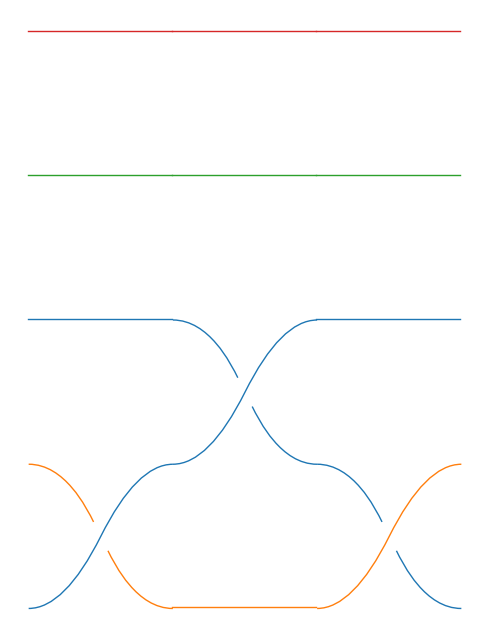

Simplified applied: True
After simplify: Torus Knot:
  Binary list 1: [1, 0, 0]
  Binary list 2: [0, 0, 1]
  Braid: s1*s0


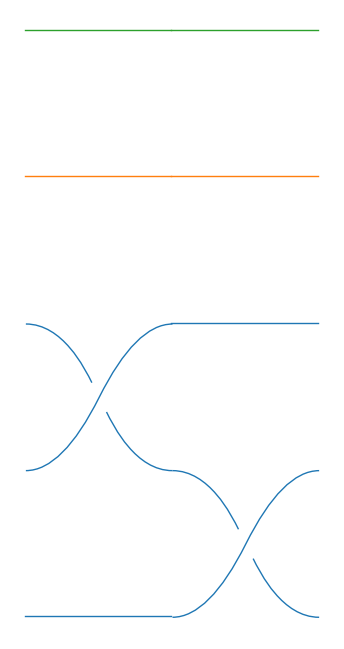

In [26]:
# Example usage of TorusKnot class

# Create a simple torus knot
list1 = [0, 1, 0]
list2 = [0, 0, 1]
braid_word = [1, 2, 1]  # A simple braid word

tk = TorusKnot(list1, list2, braid_word)
print(tk)
print(repr(tk))

# Show before-simplification state
print("Before simplify:", tk)
tk.plot_braid()

# Apply the simplification action
applied = tk.simplify_by_first_braid_letter()
print("Simplified applied:", applied)
print("After simplify:", tk)

tk.plot_braid()

#tk2 = TorusKnot(list1, list2, [2, 1, 2])
#tk2.plot_braid()